# 一、二维达西控制方程物理模型
## 1. 控制方程
稳态无汇源二维达西渗流：
$$
-\nabla \cdot (\kappa(x,y)\nabla p(x,y)) = 0,\quad (x,y)\in\Omega=[0,1]\times[0,1]
$$

展开形式：
$$
-\frac{\partial}{\partial x}\left(\kappa \frac{\partial p}{\partial x}\right)
-\frac{\partial}{\partial y}\left(\kappa \frac{\partial p}{\partial y}\right) = 0
$$

通量分量：$q_x = -\kappa \frac{\partial p}{\partial x},\ q_y = -\kappa \frac{\partial p}{\partial y}$，全域通量散度为 0。

## 2. 两套对照算例（对标一维 Case1/Case2）
### Case A：均质二维介质 $\kappa(x,y) \equiv 1$（对标一维 Case1）
方程退化为拉普拉斯方程：
$$
-\frac{\partial^2 p}{\partial x^2} - \frac{\partial^2 p}{\partial y^2} = 0
$$

边界条件（四边 Dirichlet）：
$$
\begin{cases}
p(0,y)=1,\ p(1,y)=0,\quad &0 \le y \le 1\\
p(x,0)=1-x,\ p(x,1)=1-x,\quad &0 \le x \le 1
\end{cases}
$$

解析解：$p(x,y)=1-x$，和一维解完全一致，与 $y$ 无关。

### Case B：分段不连续二维渗透率（对标一维 Case2）
分块三层介质，$x$ 方向分段，$y$ 全域均匀：
$$
\kappa(x,y) =
\begin{cases}
1, & 0 \le x < 0.4, \ 0 \le y \le 1\\
0.1, & 0.4 \le x < 0.6,\ 0 \le y \le 1\\
1, & 0.6 \le x \le 1, \ 0 \le y \le 1
\end{cases}
$$

边界条件和 Case A 完全相同，解析解沿用一维分段形式 $p(x,y)=p_{1D}(x)$，与 $y$ 无关。

新增约束：$x=0.4、x=0.6$ 两条竖直线上通量法向分量 $q_x=\kappa \frac{\partial p}{\partial x}$ 连续。

## 3. 一维→二维核心改动点
1. 网络输入由 $[x]$ 一维张量改为 $[x,y]$ 二维坐标输入；
2. 自动微分需要同时求 $\frac{\partial p}{\partial x},\frac{\partial p}{\partial y},\frac{\partial^2 p}{\partial x^2},\frac{\partial^2 p}{\partial y^2}$；
3. PDE 残差包含 $x、y$ 两个方向通量导数；
4. 采样从一维线段采样改为二维矩形区域均匀采样；
5. 界面损失改为两条竖直线 $x=0.4、0.6$ 全线通量连续约束；
6. 边界损失需要约束矩形四条边。

1. 公共基础模块（导入、设备、网络、高阶微分函数，复用一维逻辑）

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

# 设备自动选择
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on device:", device)

# 通用高阶自动微分函数（二维完全复用，自动支持多输入）
def grad(y, x):
    return torch.autograd.grad(
        outputs=y,
        inputs=x,
        create_graph=True,
        grad_outputs=torch.ones_like(y),
        retain_graph=True
    )[0]

# 全连接神经网络：输入2维(x,y)，输出1维压力p
class Net2D(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=40, output_dim=1, num_layers=4):
        super().__init__()
        self.layers = []
        # 输入层 2→40
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        self.layers.append(nn.Tanh())
        # 隐藏层循环
        for i in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.layers.append(nn.Tanh())
        # 输出层 40→1
        self.layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*(self.layers))
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, xy):
        # xy: [N,2] 张量，每一行是(x,y)坐标对
        return self.net(xy)

# 初始化网络
model_2d = Net2D().to(device)
# 输入维度(1,2)：单组二维坐标(x,y)
summary(model_2d, (1, 2))

Running on device: cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 40]             120
              Tanh-2                [-1, 1, 40]               0
            Linear-3                [-1, 1, 40]           1,640
              Tanh-4                [-1, 1, 40]               0
            Linear-5                [-1, 1, 40]           1,640
              Tanh-6                [-1, 1, 40]               0
            Linear-7                [-1, 1, 40]           1,640
              Tanh-8                [-1, 1, 40]               0
            Linear-9                 [-1, 1, 1]              41
Total params: 5,081
Trainable params: 5,081
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
------------------------

2. Case A：均质二维介质 κ=1（拉普拉斯方程，对标一维 Case1)

2.1 PDE 残差损失（二维拉普拉斯算子 ΔP=P xx+P yy ）

In [8]:
def pde_loss_homo(model, xy):
    xy.requires_grad_(True)
    p = model(xy)[:, 0:1]
    # 一阶偏导 ∂p/∂x, ∂p/∂y
    dp_dxy = grad(p, xy)
    dp_dx = dp_dxy[:, 0:1]
    dp_dy = dp_dxy[:, 1:2]
    # 二阶偏导 ∂²p/∂x²
    d2p_dx2 = grad(dp_dx, xy)[:, 0:1]
    # 二阶偏导 ∂²p/∂y²
    d2p_dy2 = grad(dp_dy, xy)[:, 1:2]
    # 拉普拉斯残差 Δp = p_xx + p_yy，目标残差=0
    laplace = d2p_dx2 + d2p_dy2
    loss = torch.mean(laplace ** 2)
    return loss

2.2 四边 Dirichlet 边界损失（软边界，对标一维 bc_loss）

In [9]:
def bc_loss_homo(model):
    # 四条边界采样点
    # 左边界 x=0, y∈[0,1]
    # 在y轴0~1均匀取50个采样点，一维列向量 [50,1]
    y_b_left = torch.linspace(0, 1, 50, device=device).view(-1, 1) ###把维度1D-->2D
    # 拼接x=0和y，生成二维坐标矩阵 [50,2]，每行是(0, y_i)
    xy_left = torch.cat([torch.zeros_like(y_b_left), y_b_left], dim=1) ### torch.cat([A,B,dim=1])
    # 左边界真值全为1，和y同尺寸张量
    p_true_left = torch.ones_like(y_b_left)

    # 右边界 x=1, y∈[0,1]
    y_b_right = torch.linspace(0, 1, 50, device=device).view(-1, 1)
    xy_right = torch.cat([torch.ones_like(y_b_right), y_b_right], dim=1)
    p_true_right = torch.zeros_like(y_b_right)

    # 下边界 y=0, x∈[0,1]
    x_b_bottom = torch.linspace(0, 1, 50, device=device).view(-1, 1)
    xy_bottom = torch.cat([x_b_bottom, torch.zeros_like(x_b_bottom)], dim=1)
    p_true_bottom = 1 - x_b_bottom

    # 上边界 y=1, x∈[0,1]
    x_b_top = torch.linspace(0, 1, 50, device=device).view(-1, 1)
    xy_top = torch.cat([x_b_top, torch.ones_like(x_b_top)], dim=1)
    p_true_top = 1 - x_b_top

    # 合并所有边界点与真值
    xy_b = torch.cat([xy_left, xy_right, xy_bottom, xy_top], dim=0)
    p_true_b = torch.cat([p_true_left, p_true_right, p_true_bottom, p_true_top], dim=0)
    p_pred_b = model(xy_b)[:, 0:1]

    loss = torch.mean((p_pred_b - p_true_b) ** 2)
    return loss

2.3 二维区域采样（矩形域 
[0,1]×[0,1]
 均匀随机采样）

In [10]:
def sample_domain_2d(num_sample):
    x_rand = torch.rand(num_sample, 1, device=device)
    y_rand = torch.rand(num_sample, 1, device=device)
    xy_sample = torch.cat([x_rand, y_rand], dim=1)
    xy_sample.requires_grad_(True)
    return xy_sample

2.4 Case A 训练循环

In [11]:
# 超参
num_f = 3000
num_epochs = 10000
lr = 1e-3

model_A = Net2D().to(device)
optimizer = optim.Adam(model_A.parameters(), lr=lr)
loss_history = []
pde_history = []
bc_history = []

# 生成二维内部采样点
xy_f = sample_domain_2d(num_f)

for epoch in range(num_epochs):
    loss_pde = pde_loss_homo(model_A, xy_f)
    loss_bc = bc_loss_homo(model_A)
    total_loss = loss_pde + loss_bc

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    loss_history.append(total_loss.item())
    pde_history.append(loss_pde.item())
    bc_history.append(loss_bc.item())

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Total:{total_loss.item():.4e} | PDE:{loss_pde.item():.4e} | BC:{loss_bc.item():.4e}")

Epoch 1000/10000 | Total:2.7879e-05 | PDE:2.6580e-05 | BC:1.2990e-06
Epoch 2000/10000 | Total:1.0949e-05 | PDE:1.0174e-05 | BC:7.7530e-07
Epoch 3000/10000 | Total:7.0984e-06 | PDE:6.6545e-06 | BC:4.4393e-07
Epoch 4000/10000 | Total:5.6068e-06 | PDE:5.3416e-06 | BC:2.6528e-07
Epoch 5000/10000 | Total:3.8555e-06 | PDE:3.6629e-06 | BC:1.9254e-07
Epoch 6000/10000 | Total:3.5968e-06 | PDE:3.4870e-06 | BC:1.0979e-07
Epoch 7000/10000 | Total:2.8675e-05 | PDE:4.2509e-06 | BC:2.4425e-05
Epoch 8000/10000 | Total:2.3461e-06 | PDE:2.3089e-06 | BC:3.7204e-08
Epoch 9000/10000 | Total:1.5075e-06 | PDE:1.4929e-06 | BC:1.4670e-08
Epoch 10000/10000 | Total:1.1502e-06 | PDE:1.1487e-06 | BC:1.4826e-09


2.5 二维云图绘图函数（对比解析解 
p=1−x
）

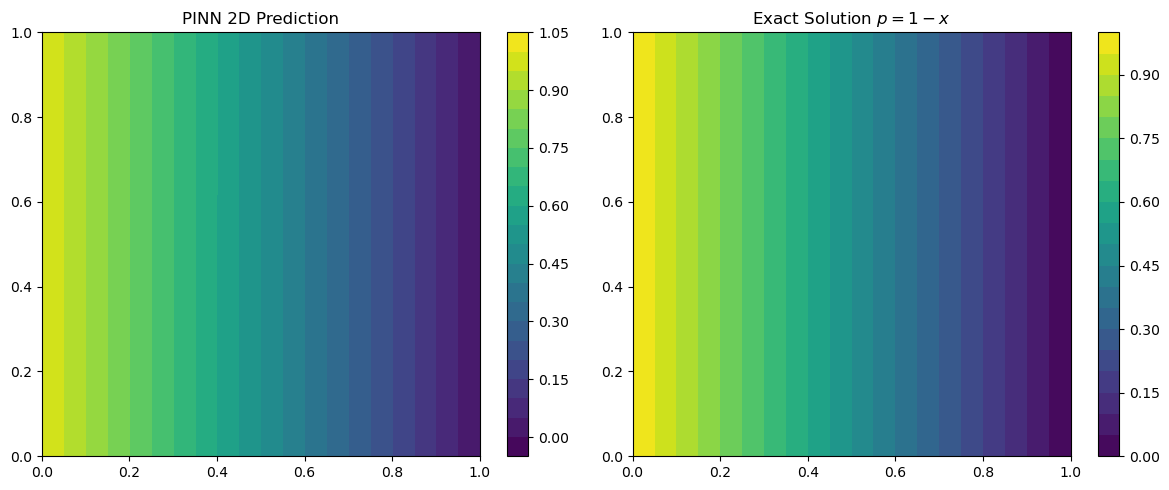

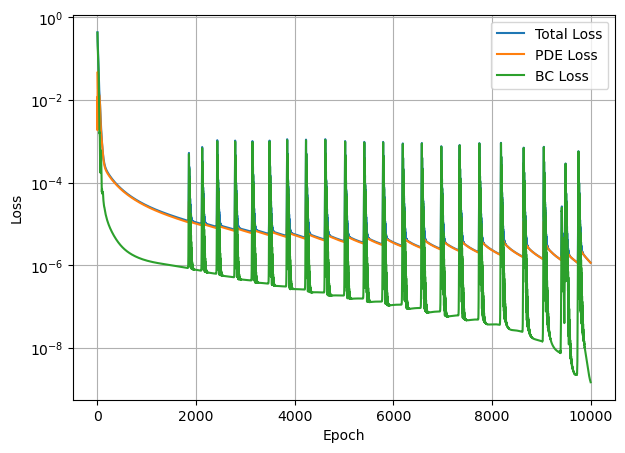

In [13]:
def plot_2d_contour(model):
    # 生成网格
    x_grid = torch.linspace(0, 1, 100, device=device)
    y_grid = torch.linspace(0, 1, 100, device=device)
    X, Y = torch.meshgrid(x_grid, y_grid, indexing="xy")
    xy_grid = torch.stack([X.ravel(), Y.ravel()], dim=1)

    with torch.no_grad():
        p_pred = model(xy_grid)[:,0].cpu().numpy().reshape(X.shape)
        p_exact = (1 - X).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    # PINN预测云图
    c1 = axes[0].contourf(X.cpu(), Y.cpu(), p_pred, levels=20)
    axes[0].set_title("PINN 2D Prediction")
    plt.colorbar(c1, ax=axes[0])
    # 解析解云图
    c2 = axes[1].contourf(X.cpu(), Y.cpu(), p_exact, levels=20)
    axes[1].set_title("Exact Solution $p=1-x$")
    plt.colorbar(c2, ax=axes[1])
    plt.tight_layout()
    plt.show()

# 训练完成后调用
plot_2d_contour(model_A)

# 损失曲线
plt.figure(figsize=(7,5))
plt.semilogy(loss_history, label="Total Loss")
plt.semilogy(pde_history, label="PDE Loss")
plt.semilogy(bc_history, label="BC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()